# MVP Análise de Dados e Boas Práticas

**Nome:** Marcela Stein

**Matrícula:** 456607

**Dataset:** [Military Expenditure](https://www.kaggle.com/datasets/nitinsss/military-expenditure-of-countries-19602019/data)



# Descrição do Problema

O conjunto de dados Military Expenditure é um conjunto de dados multivariado que consiste em apresentar os dados históricos de gastos militares anuais, expressos em valores correntes em dólares (USD), para países, regiões semiautônomas, agrupamentos regionais (geográficos ou econômicos) e o total mundial, no período de 1960 a 2018.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **A Europa foi a região que mais investiu em gastos militares ao longo do período 1960–2018?**

2. **Países do mesmo continente apresentam comportamento semelhante de investimento militar?**

3. **Países desenvolvidos apresentam menor volatilidade no gasto militar**

## Tipo de Problema
O problema pode ser classificado em dois tipo:

 **1 - Regressão supervisionada**. São utilizados dados históricos do gastos militares por regiões (ex: países e agrupamento de regiões). Por meio dos dados podemos prever quais são os futuros gastos.

  **2 - Clasterização**. É possível obter grupos com perfil semelhante das regiões.

## Seleção de Dados

O dataset Iris é um conjunto de dados amplamente disponível e frequentemente incluído em bibliotecas de aprendizado de máquina, como *scikit-learn* no Python. Não é necessária uma etapa de seleção de dados externa, pois o dataset já está curado e pronto para uso.

## Atributos do Dataset

O dataset Iris contém 150 amostras, com 50 amostras de cada uma das três espécies de Íris. Possui cinco atributos:

- ***sepal length*** (comprimento da sépala em cm)
- ***sepal width*** (largura da sépala em cm)
- ***petal length*** (comprimento da pétala em cm)
- ***petal width*** (largura da pétala em cm)
- ***species*** (espécie de Íris: setosa, versicolor, virginica)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [23]:
# carregamento do dataset (aqui, ele fica disponível nesse método)
# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/marcelastein/MVP-Analise_Gastos_Militares/main/Military%20Expenditure.csv"

# Lê o arquivo
dataset = pd.read_csv(url,sep=",")

#Criar uma cópia do dataset
df = dataset.copy()

# Exibindo as primeiras linhas
df.head()

,Name,Code,Type,Indicator Name,1960,1961,1962,1963,1964,1965,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,NaN,...,2.518695e+08,2.981469e+08,3.258070e+08,2.385834e+08,2.171941e+08,2.682271e+08,1.995186e+08,1.858783e+08,1.914071e+08,1.980863e+08
2,Angola,AGO,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,NaN,...,3.311193e+09,3.500795e+09,3.639496e+09,4.144635e+09,6.090752e+09,6.841864e+09,3.608299e+09,2.764055e+09,3.062873e+09,1.983614e+09
3,Albania,ALB,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,NaN,...,1.827369e+08,1.858932e+08,1.970068e+08,1.832047e+08,1.800155e+08,1.781204e+08,1.323507e+08,1.308532e+08,1.443827e+08,1.804887e+08
4,Andorra,AND,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# ultimas linhas linhas
df.tail()

,Name,Code,Type,Indicator Name,1960,1961,1962,1963,1964,1965,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
259,Kosovo,XKX,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,NaN,...,2.722709e+07,3.857812e+07,5.096886e+07,4.339040e+07,4.859768e+07,5.357579e+07,4.998416e+07,5.193762e+07,5.726263e+07,6.334407e+07
260,"Yemen, Rep.",YEM,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,NaN,...,1.420775e+09,1.448153e+09,1.612254e+09,1.618840e+09,1.648751e+09,1.714831e+09,NaN,NaN,NaN,NaN
261,South Africa,ZAF,Country,Military expenditure (current USD),69999972.0,113749954.5,186199925.5,188999924.4,271599891.4,289449884.2,...,3.592688e+09,4.188168e+09,4.594154e+09,4.489590e+09,4.118208e+09,3.892469e+09,3.488868e+09,3.169756e+09,3.638937e+09,3.639879e+09
262,Zambia,ZMB,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,NaN,...,2.209623e+08,2.801878e+08,3.091138e+08,3.463014e+08,3.813458e+08,4.436044e+08,3.724476e+08,2.995048e+08,3.396645e+08,3.780254e+08
263,Zimbabwe,ZWE,Country,Military expenditure (current USD),NaN,NaN,NaN,NaN,NaN,15600000.0,...,NaN,9.829300e+07,1.984380e+08,3.182720e+08,3.567000e+08,3.681000e+08,3.766770e+08,3.580650e+08,3.405220e+08,4.203640e+08


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Military Expenditure, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Military Expenditure possui 264 instâncias (observações), cada instância representa uma região. As quatro primeiras colunas ('name', 'Code', 'Type' e 'Indicador Name") são do tipo categórico (string - object para o pacote pandas). Os outros dados, que representam os anos, são do tipo numérico (float).

As intâncias são dividas em Tipo que estão classificadas na coluna 'type'. O tipo que tem maior predominância é o 'country' com 202 instâncias (  

In [32]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 264

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 63 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            264 non-null    object 
 1   Code            264 non-null    object 
 2   Type            264 non-null    object 
 3   Indicator Name  264 non-null    object 
 4   1960            79 non-null     float64
 5   1961            84 non-null     float64
 6   1962            93 non-null     float64
 7   1963            98 non-null     float64
 8   1964            98 non-null     float64
 9   1965            104 non-null    float64
 10  1966            104 non-null    float64
 11  1967            105 non-null    float64
 12  1968            113 non-null    float64
 13  1969            113 non-null    float64
 14  1970            121 non-null    float64
 15  1971            122 non-null    float64
 16  1972            123 non-nul

Type
Country                           0.765152
Regions Clubbed Economically      0.125000
Semi Autonomous Region            0.068182
Regions Clubbed Geographically    0.041667
Name: count, dtype: float64


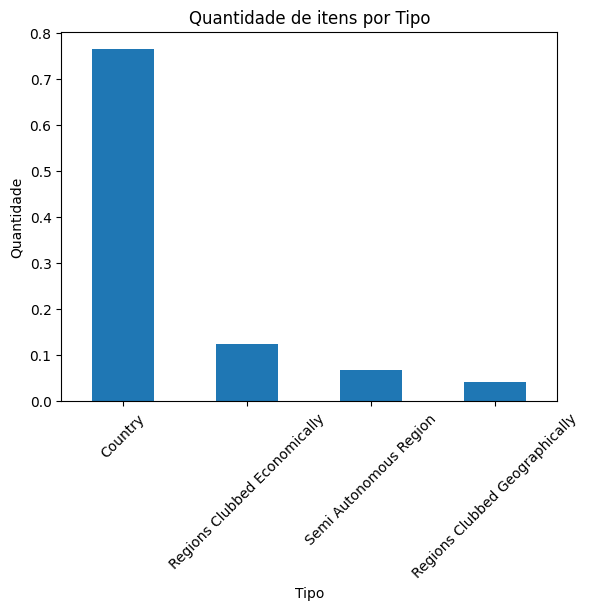

In [38]:
contagem = df["Type"].value_counts()
print(contagem)
contagem.plot(kind="bar")

plt.title("Quantidade de itens por Tipo")
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)

plt.show()

O gráfico de barras mostra que cada espécie de Íris (setosa, versicolor, virginica) possui 50 amostras, confirmando que o dataset é balanceado em termos de classes.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [27]:
# estatísticas descritivas básicas do dataset
df.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
count,7.900000e+01,8.400000e+01,9.300000e+01,9.800000e+01,9.800000e+01,1.040000e+02,1.040000e+02,1.050000e+02,1.130000e+02,1.130000e+02,...,1.970000e+02,1.960000e+02,1.940000e+02,1.990000e+02,2.020000e+02,2.030000e+02,1.980000e+02,1.970000e+02,1.950000e+02,1.960000e+02
mean,4.482374e+09,4.450649e+09,4.520297e+09,4.462435e+09,4.525730e+09,4.429380e+09,5.098436e+09,5.757744e+09,5.661456e+09,5.866198e+09,...,5.919239e+10,6.289206e+10,6.823127e+10,6.767465e+10,6.782427e+10,6.788223e+10,6.553286e+10,6.562135e+10,6.927640e+10,7.216267e+10
std,1.447959e+10,1.486998e+10,1.560037e+10,1.551553e+10,1.552208e+10,1.544076e+10,1.817987e+10,2.092876e+10,2.133673e+10,2.175941e+10,...,1.976434e+11,2.067953e+11,2.188292e+11,2.152426e+11,2.112636e+11,2.095356e+11,2.002215e+11,2.008000e+11,2.091964e+11,2.202652e+11
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.205030e+07,2.571702e+07,2.484204e+07,2.866130e+07,3.662134e+07,3.396381e+07,3.803623e+07,3.554479e+07,2.040000e+07,2.286154e+07,...,2.148242e+08,2.195343e+08,2.592131e+08,2.309348e+08,2.510677e+08,2.491632e+08,2.488889e+08,2.607297e+08,2.851254e+08,2.945764e+08
50%,1.408889e+08,1.200573e+08,1.700342e+08,1.824402e+08,1.891038e+08,2.048374e+08,2.388078e+08,2.519307e+08,2.727273e+08,2.636364e+08,...,2.115785e+09,2.136473e+09,2.484600e+09,2.589776e+09,2.435637e+09,2.355992e+09,2.415996e+09,2.455784e+09,2.328157e+09,2.406164e+09
75%,8.240486e+08,7.590874e+08,8.332295e+08,8.987564e+08,1.144744e+09,8.919075e+08,1.009040e+09,1.123833e+09,1.119925e+09,1.380000e+09,...,1.783128e+10,1.682419e+10,1.823214e+10,1.875641e+10,1.937015e+10,2.031822e+10,1.927764e+10,1.785398e+10,2.147698e+10,1.832208e+10
max,6.777699e+10,7.161496e+10,7.889139e+10,8.097281e+10,8.148150e+10,8.364532e+10,9.752720e+10,1.120000e+11,1.180000e+11,1.210000e+11,...,1.550000e+12,1.630000e+12,1.730000e+12,1.740000e+12,1.740000e+12,1.740000e+12,1.640000e+12,1.630000e+12,1.700000e+12,1.780000e+12


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [39]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
1960,4.482374e+09
1961,4.450649e+09
1962,4.520297e+09
1963,4.462435e+09
1964,4.525730e+09
1965,4.429380e+09
1966,5.098436e+09
1967,5.757744e+09
1968,5.661456e+09
1969,5.866198e+09


In [ ]:
# Qual gráfico seria interessante usar pra mostrar a média?

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

In [ ]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *sepal length*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(df['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição do comprimento da sépala. A curva de densidade estimada (KDE) nos indica que a distribuição parece bimodal ou multimodal, indicando que as espécies podem ter comprimentos de sépalas diferentes.

### *sepal width*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(df['sepal width (cm)'], kde=True)
plt.title('Distribuição da Largura da Sépala')
plt.xlabel('Largura da Sépala (cm)')
plt.ylabel('Frequência')
plt.show()

Quais impressões você tem sobre a distribuição do atributo 'sepal width'?

## Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por espécie
df.groupby('species').describe()

### *petal length* por Espécie


In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal length (cm)', data=df)
plt.title('Comprimento da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Comprimento da Pétala (cm)')
plt.show()

O boxplot do comprimento da pétala por espécie demonstra claramente que a Iris setosa tem pétalas significativamente mais curtas do que as outras duas espécies. Há uma sobreposição entre Iris versicolor e Iris virginica, mas as medianas e as caixas indicam uma distinção.

### *petal width* por Espécie

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal width (cm)', data=df)
plt.title('Largura da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Largura da Pétala (cm)')
plt.show()

Quais impressões o boxplot trouxe?

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df.iloc[:, :4].corr()

In [ ]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Iris Dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
df.isnull().sum()

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [ ]:
# Separar features (X) e target (y)
X = df.drop('species', axis=1)
y = df['species']

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (105, 4)
Dimensões de X_test: (45, 4)
Dimensões de y_train: (105,)
Dimensões de y_test: (45,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          0.208333           0.327586          0.416667
1           0.527778          0.083333           0.586207          0.583333
2           0.222222          0.750000           0.068966          0.083333
3           0.694444          0.500000           0.827586          0.916667
4           0.388889          0.333333           0.517241          0.500000


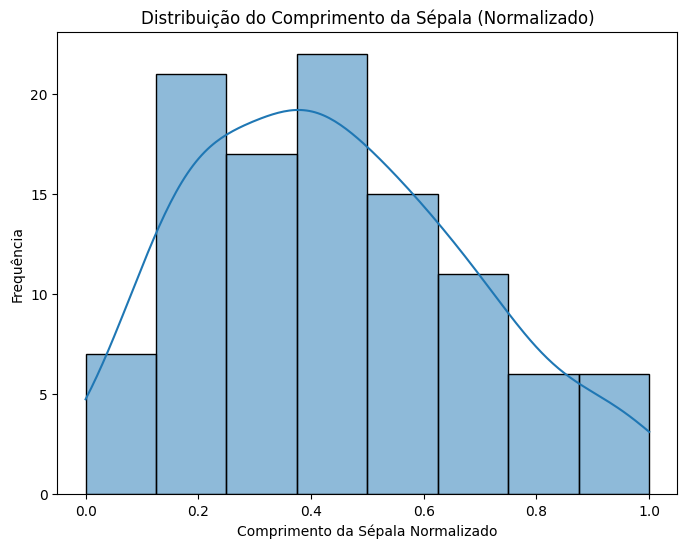

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Normalizado)')
plt.xlabel('Comprimento da Sépala Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900459         -1.220248          -0.441986         -0.136610
1           0.380366         -1.879558           0.402829          0.380294
2          -0.900459          1.636764          -1.286801         -1.170419
3           1.078998          0.318143           1.191323          1.414103
4          -0.201827         -0.560937           0.177545          0.121842


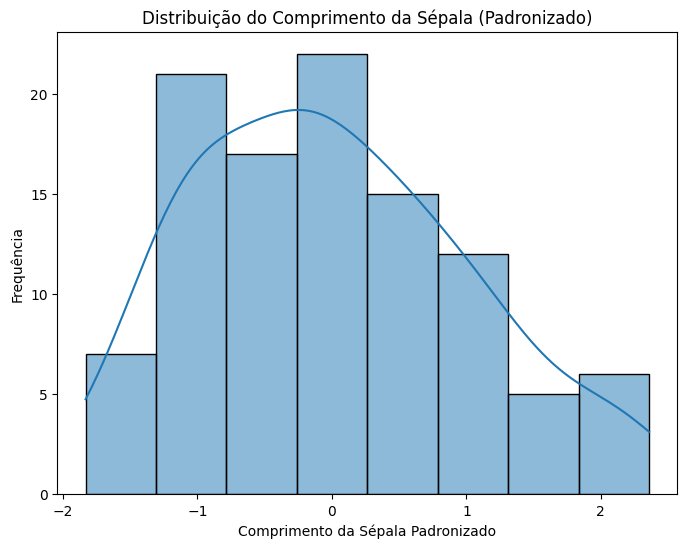

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['sepal length (cm)'], kde=True)
plt.title('Distribuição do Comprimento da Sépala (Padronizado)')
plt.xlabel('Comprimento da Sépala Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

In [ ]:
# hipótese 1

## Hipótese 2

In [ ]:
# hipótese 2

## Hipótese 3

In [ ]:
# hipótese 3

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.